# EDA и проверка данных на аномалии

Диагностика до моделирования: целостность ключей, временная структура и стабильность таргета,
пропуски, монотонность оконных агрегатов, поиск утечек (в т.ч. окно `event_ts ≥ assignment_ts`
в events), дрейф train→test и полезность событий.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (11, 4)
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 160)

DATA_DIR = Path("data")
TARGET = "target"
ID_COLUMNS = ["lead_id", "user_id"]
TIME_COLUMNS = ["assignment_ts", "assignment_date"]

WINDOWS = ["1d", "3d", "7d", "14d", "30d", "90d"]
TARGET_HORIZON_DAYS = 5

In [2]:
train = pd.read_csv(DATA_DIR / "train.csv", parse_dates=["assignment_ts"])
test = pd.read_csv(DATA_DIR / "test.csv", parse_dates=["assignment_ts"])
events = pd.read_csv(DATA_DIR / "events.csv", parse_dates=["event_ts"])

train["assignment_date"] = pd.to_datetime(train["assignment_date"]).dt.date
test["assignment_date"] = pd.to_datetime(test["assignment_date"]).dt.date

print("train:", train.shape)
print("test :", test.shape)
print("events:", events.shape)
print("target mean:", round(train[TARGET].mean(), 4))
print("mem train MB:", round(train.memory_usage(deep=True).sum() / 1e6, 1))

train: (13694, 119)
test : (4306, 118)
events: (254705, 7)
target mean: 0.2075
mem train MB: 14.4


## 1. Целостность ключей
Дубли `lead_id`, пересечение train/test, один `user_id` на lead, согласованность дат.

In [3]:
def key_health(train, test, events):
    report = {}
    report["train_dup_lead"] = int(train["lead_id"].duplicated().sum())
    report["test_dup_lead"] = int(test["lead_id"].duplicated().sum())
    report["train_test_overlap"] = len(set(train["lead_id"]) & set(test["lead_id"]))

    date_from_ts = train["assignment_ts"].dt.date
    report["date_ts_mismatch"] = int((date_from_ts != train["assignment_date"]).sum())

    users_per_lead = events.groupby("lead_id")["user_id"].nunique()
    report["events_leads_multi_user"] = int((users_per_lead > 1).sum())
    return report


for k, v in key_health(train, test, events).items():
    print(f"{k:28s}: {v}")

train_dup_lead              : 0
test_dup_lead               : 0
train_test_overlap          : 0
date_ts_mismatch            : 0
events_leads_multi_user     : 0


## 2. Временная структура и стабильность таргета
Метрика усредняется по дням, поэтому смотрим распределение таргета/объёма по датам и что сплит
train/test строго временной.

In [4]:
print("train assignment:", train["assignment_ts"].min(), "->", train["assignment_ts"].max())
print("test  assignment:", test["assignment_ts"].min(), "->", test["assignment_ts"].max())
print("events ts       :", events["event_ts"].min(), "->", events["event_ts"].max())
print()
gap = pd.Timestamp(min(test["assignment_ts"])) - pd.Timestamp(max(train["assignment_ts"]))
print("зазор между концом train и началом test:", gap)

daily = train.groupby("assignment_date").agg(
    n_leads=("lead_id", "size"),
    target_rate=(TARGET, "mean"),
    n_positive=(TARGET, "sum"),
).reset_index()
daily

train assignment: 2026-04-07 09:02:00 -> 2026-04-22 21:58:00
test  assignment: 2026-04-23 09:00:00 -> 2026-04-27 21:59:00
events ts       : 2026-03-08 10:03:00 -> 2026-04-27 20:28:00

зазор между концом train и началом test: 0 days 11:02:00


,assignment_date,n_leads,target_rate,n_positive
0,2026-04-07,873,0.223368,195
1,2026-04-08,832,0.209135,174
2,2026-04-09,859,0.206054,177
3,2026-04-10,830,0.220482,183
4,2026-04-11,861,0.203252,175
5,2026-04-12,855,0.203509,174
6,2026-04-13,791,0.206068,163
7,2026-04-14,842,0.197150,166
8,2026-04-15,899,0.199110,179
9,2026-04-16,854,0.203747,174


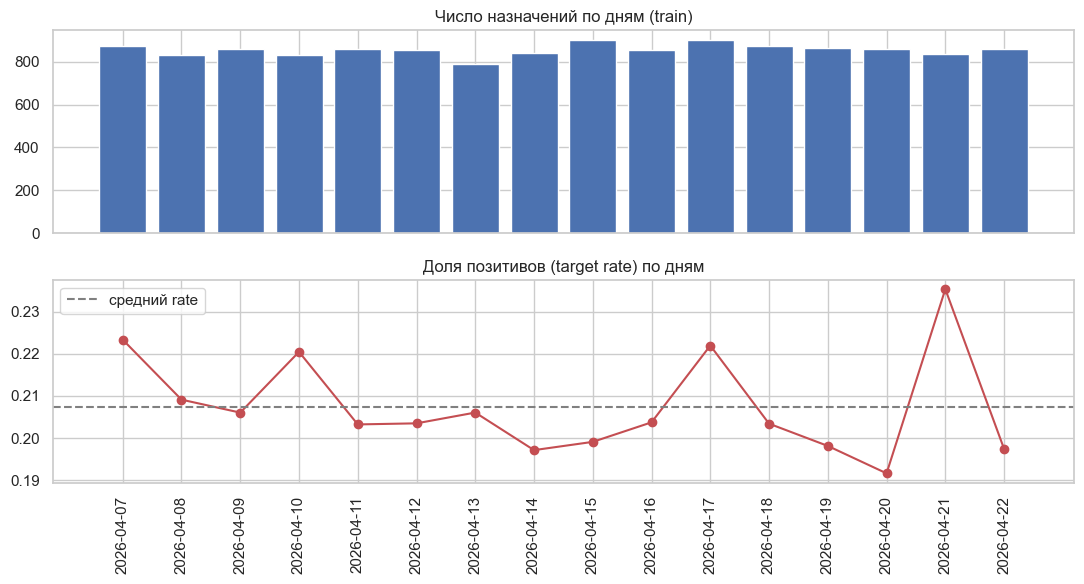

target rate по дням: min=0.192  max=0.235  std=0.0118


In [5]:
fig, ax = plt.subplots(2, 1, figsize=(11, 6), sharex=True)
ax[0].bar(daily["assignment_date"].astype(str), daily["n_leads"], color="#4C72B0")
ax[0].set_title("Число назначений по дням (train)")
ax[0].tick_params(axis="x", rotation=90)

ax[1].plot(daily["assignment_date"].astype(str), daily["target_rate"], marker="o", color="#C44E52")
ax[1].axhline(train[TARGET].mean(), ls="--", color="gray", label="средний rate")
ax[1].set_title("Доля позитивов (target rate) по дням")
ax[1].legend()
ax[1].tick_params(axis="x", rotation=90)
plt.tight_layout()
plt.show()

print("target rate по дням: min=%.3f  max=%.3f  std=%.4f" % (
    daily["target_rate"].min(), daily["target_rate"].max(), daily["target_rate"].std()))

## 3. Пропуски и распределения
Доля пропусков по колонкам + проверка `_log`-признаков на нефизичные значения.

In [6]:
def missing_report(df):
    miss = df.isna().mean().sort_values(ascending=False)
    miss = miss[miss > 0]
    return miss.rename("missing_frac").to_frame()

miss = missing_report(train)
print("колонок с пропусками:", len(miss))
miss.head(20)

колонок с пропусками: 97


,missing_frac
seller_response_rate_30d,0.051701
leadgen_prev_positive_90d,0.033007
item_favorites_3d,0.032934
query_refinements_30d,0.032569
detail_expands_3d,0.032496
user_contacts_3d,0.031839
leadgen_prev_assigned_7d,0.031766
call_clicks_14d,0.031693
user_contacts_14d,0.031620
call_clicks_30d,0.031620


In [7]:
suspect = {}
for col in ["car_age_years", "mileage_km_log", "item_price_log", "user_age_days",
            "seller_inventory_count", "seller_response_rate_30d"]:
    if col in train.columns:
        s = train[col]
        suspect[col] = {
            "min": round(float(s.min()), 3),
            "max": round(float(s.max()), 3),
            "neg_frac": round(float((s < 0).mean()), 4),
            "na_frac": round(float(s.isna().mean()), 4),
        }
pd.DataFrame(suspect).T

,min,max,neg_frac,na_frac
car_age_years,0.000,14.544,0.0,0.0000
mileage_km_log,7.881,13.690,0.0,0.0000
item_price_log,11.199,14.927,0.0,0.0000
user_age_days,1.000,4088.000,0.0,0.0000
seller_inventory_count,1.000,184.000,0.0,0.0000
seller_response_rate_30d,0.042,0.961,0.0,0.0517


## 4. Монотонность оконных агрегатов
Инвариант `feature_1d ≤ feature_3d ≤ ... ≤ feature_90d`; доля нарушений по семействам.

In [8]:
def window_families(columns):
    families = {}
    for col in columns:
        for w in WINDOWS:
            suffix = "_" + w
            if col.endswith(suffix):
                families.setdefault(col[: -len(suffix)], {})[w] = col
    return {base: cols for base, cols in families.items() if len(cols) >= 2}


def monotonicity_report(df, families):
    rows = []
    for base, cols in families.items():
        ordered = [cols[w] for w in WINDOWS if w in cols]
        block = df[ordered]
        diffs = block.diff(axis=1).iloc[:, 1:]
        violation_rows = (diffs < -1e-9).any(axis=1)
        rows.append({
            "family": base,
            "n_windows": len(ordered),
            "violation_frac": round(float(violation_rows.mean()), 5),
        })
    return pd.DataFrame(rows).sort_values("violation_frac", ascending=False)


families = window_families(train.columns)
print("семейств оконных признаков:", len(families))
mono = monotonicity_report(train, families)
mono

семейств оконных признаков: 16


,family,n_windows,violation_frac
4,seller_page_views,6,0.56141
15,active_days_auto,6,0.47933
2,detail_expands,6,0.47364
8,saved_search_matches,6,0.47313
9,user_contacts,6,0.47137
1,item_favorites,6,0.47028
6,query_refinements,6,0.46458
7,similar_item_clicks,6,0.46064
10,chat_opens,6,0.45969
11,call_clicks,6,0.45604


## 5. Поиск утечек: сила одиночного признака
Аномально высокая одиночная Daily AP → признак либо очень силён, либо с информацией из будущего.
Считаем метрику одним признаком как score (в обе стороны знака).

In [9]:
def average_precision(y_true, y_score):
    order = np.argsort(-y_score, kind="mergesort")
    y = y_true[order]
    n_pos = y.sum()
    if n_pos == 0:
        return np.nan
    cum_tp = np.cumsum(y)
    k = np.arange(1, len(y) + 1)
    precision_at_k = cum_tp / k
    return float(np.sum(precision_at_k * y) / n_pos)


def daily_average_precision(y_true, y_score, dates):
    frame = pd.DataFrame({"y": y_true, "s": y_score, "d": dates})
    scores = []
    for _, g in frame.groupby("d"):
        ap = average_precision(g["y"].to_numpy(), g["s"].to_numpy())
        if not np.isnan(ap):
            scores.append(ap)
    return float(np.mean(scores)) if scores else np.nan


numeric_features = [
    c for c in train.columns
    if c not in ID_COLUMNS + TIME_COLUMNS + [TARGET]
    and pd.api.types.is_numeric_dtype(train[c])
]

y = train[TARGET].to_numpy()
dates = train["assignment_date"].to_numpy()

rows = []
for col in numeric_features:
    s = train[col].fillna(train[col].median()).to_numpy()
    ap_pos = daily_average_precision(y, s, dates)
    ap_neg = daily_average_precision(y, -s, dates)
    rows.append({"feature": col, "daily_ap": max(ap_pos, ap_neg),
                 "direction": "high->1" if ap_pos >= ap_neg else "low->1"})

single = pd.DataFrame(rows).sort_values("daily_ap", ascending=False)
base_rate = train[TARGET].mean()
print("базовый rate (случайный Daily AP ~):", round(base_rate, 4))
single.head(20)

базовый rate (случайный Daily AP ~): 0.2075


,feature,daily_ap,direction
46,search_views_90d,0.377526,high->1
16,item_views_90d,0.371145,high->1
14,item_views_14d,0.363500,high->1
15,item_views_30d,0.363461,high->1
45,search_views_30d,0.357843,high->1
33,photo_swipes_30d,0.357115,high->1
3,user_active_days_30d,0.356000,high->1
44,search_views_14d,0.354408,high->1
106,active_days_auto_90d,0.350236,high->1
13,item_views_7d,0.347569,high->1


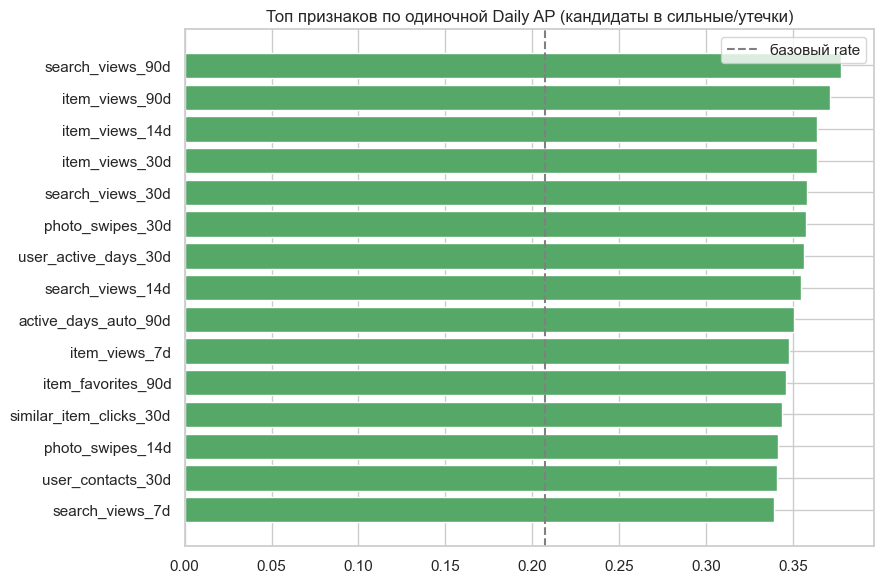

In [10]:
top = single.head(15).iloc[::-1]
plt.figure(figsize=(9, 6))
plt.barh(top["feature"], top["daily_ap"], color="#55A868")
plt.axvline(base_rate, ls="--", color="gray", label="базовый rate")
plt.title("Топ признаков по одиночной Daily AP (кандидаты в сильные/утечки)")
plt.legend()
plt.tight_layout()
plt.show()

## 6. Дрейф train → test
Числовые — PSI (`<0.1` ок, `0.1–0.25` умеренный, `>0.25` сильный). Категориальные — доля строк
test с новыми категориями.

In [11]:
def population_stability_index(expected, actual, bins=10):
    expected = expected[~np.isnan(expected)]
    actual = actual[~np.isnan(actual)]
    if len(expected) == 0 or len(actual) == 0:
        return np.nan
    quantiles = np.unique(np.quantile(expected, np.linspace(0, 1, bins + 1)))
    if len(quantiles) < 3:
        return 0.0
    quantiles[0], quantiles[-1] = -np.inf, np.inf
    e_perc = np.histogram(expected, quantiles)[0] / len(expected)
    a_perc = np.histogram(actual, quantiles)[0] / len(actual)
    eps = 1e-6
    e_perc = np.clip(e_perc, eps, None)
    a_perc = np.clip(a_perc, eps, None)
    return float(np.sum((a_perc - e_perc) * np.log(a_perc / e_perc)))


psi_rows = []
for col in numeric_features:
    psi = population_stability_index(train[col].to_numpy(float), test[col].to_numpy(float))
    psi_rows.append({"feature": col, "psi": psi})

psi_df = pd.DataFrame(psi_rows).sort_values("psi", ascending=False)
print("признаков с PSI > 0.25 (сильный дрейф):", int((psi_df["psi"] > 0.25).sum()))
print("признаков с PSI > 0.10 (умеренный+):", int((psi_df["psi"] > 0.10).sum()))
psi_df.head(15)

признаков с PSI > 0.25 (сильный дрейф): 1
признаков с PSI > 0.10 (умеренный+): 1


,feature,psi
1,assignment_weekday,4.740145
9,car_age_years,0.005625
52,query_refinements_90d,0.005398
0,assignment_hour,0.004623
105,active_days_auto_30d,0.004512
33,photo_swipes_30d,0.004240
44,search_views_14d,0.003978
10,mileage_km_log,0.003816
45,search_views_30d,0.003618
75,chat_opens_30d,0.003491


In [12]:
categorical_features = [
    c for c in train.columns
    if c not in ID_COLUMNS + TIME_COLUMNS + [TARGET]
    and not pd.api.types.is_numeric_dtype(train[c])
]

cat_rows = []
for col in categorical_features:
    train_cats = set(train[col].dropna().unique())
    test_cats = set(test[col].dropna().unique())
    novel = test_cats - train_cats
    novel_frac = test[col].isin(novel).mean() if novel else 0.0
    cat_rows.append({
        "feature": col,
        "n_train_cats": len(train_cats),
        "n_test_cats": len(test_cats),
        "novel_in_test": len(novel),
        "novel_row_frac": round(float(novel_frac), 4),
    })
pd.DataFrame(cat_rows).sort_values("novel_row_frac", ascending=False)

,feature,n_train_cats,n_test_cats,novel_in_test,novel_row_frac
0,lead_source,3,3,0,0.0
1,call_center,2,2,0,0.0
2,region,5,5,0,0.0
3,car_segment,4,4,0,0.0
4,lead_channel,4,4,0,0.0
5,user_tenure_bucket,3,3,0,0.0
6,price_bucket,3,3,0,0.0


## 7. Разбор `events.csv`

### 7.1 Состав событий

In [13]:
print("event_type:")
print(events["event_type"].value_counts())
print("\nctx_seq:")
print(events["ctx_seq"].value_counts())
print("\nсобытий на lead:")
print(events.groupby("lead_id").size().describe())
print("\nпокрытие lead событиями:")
print("  train:", round(train['lead_id'].isin(set(events['lead_id'])).mean(), 4))
print("  test :", round(test['lead_id'].isin(set(events['lead_id'])).mean(), 4))

event_type:
event_type
item_view     120905
search         61101
favorite       26333
chat_open      24797
call_click     21569
Name: count, dtype: int64

ctx_seq:
ctx_seq
c01    60728
c02    55370
c06    50496
c04    50423
c08    35455
c05      935
c07      930
c03      368
Name: count, dtype: int64

событий на lead:
count    17988.000000
mean        14.159718
std          6.592222
min          1.000000
25%          9.000000
50%         13.000000
75%         19.000000
max         35.000000
dtype: float64

покрытие lead событиями:
  train: 0.9993
  test : 0.9993


### 7.2 Окно утечки: события после назначения
`assignment_ts - event_ts < 0` → событие после назначения, внутри окна таргета → утечка.

всего событий (train-join): 197421
после назначения (утечка): 0.082
минимальная дельта, дни: -4.999
(ожидаем ~ -5 — граница окна таргета)


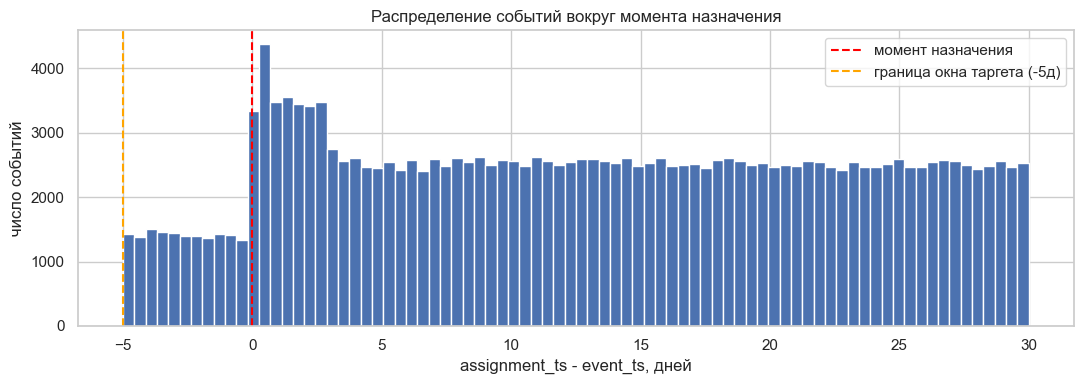

In [14]:
ev_train = events.merge(
    train[["lead_id", "assignment_ts", TARGET]], on="lead_id", how="inner"
)
ev_train["delta_days"] = (
    ev_train["assignment_ts"] - ev_train["event_ts"]
).dt.total_seconds() / 86400

after = ev_train["delta_days"] <= 0
print("всего событий (train-join):", len(ev_train))
print("после назначения (утечка): %.3f" % after.mean())
print("минимальная дельта, дни:", round(ev_train["delta_days"].min(), 3))
print("(ожидаем ~ -%d — граница окна таргета)" % TARGET_HORIZON_DAYS)

plt.figure(figsize=(11, 4))
plt.hist(ev_train["delta_days"], bins=80, color="#4C72B0")
plt.axvline(0, color="red", ls="--", label="момент назначения")
plt.axvline(-TARGET_HORIZON_DAYS, color="orange", ls="--", label="граница окна таргета (-5д)")
plt.xlabel("assignment_ts - event_ts, дней")
plt.ylabel("число событий")
plt.title("Распределение событий вокруг момента назначения")
plt.legend()
plt.tight_layout()
plt.show()

### 7.3 Постсобытия кодируют исход
`call_click`/`chat_open` после назначения должны почти идеально совпадать с `target=1`.

In [15]:
post = ev_train[ev_train["delta_days"] <= 0]
hot = post[post["event_type"].isin(["call_click", "chat_open"])]
leads_with_hot_post = set(hot["lead_id"])
flag = train["lead_id"].isin(leads_with_hot_post)
print("target rate | есть 'горячее' событие ПОСЛЕ назначения:", round(train.loc[flag, TARGET].mean(), 3))
print("target rate | нет такого события                     :", round(train.loc[~flag, TARGET].mean(), 3))
print("базовый rate:", round(train[TARGET].mean(), 3))

target rate | есть 'горячее' событие ПОСЛЕ назначения: 0.702
target rate | нет такого события                     : 0.064
базовый rate: 0.207


### 7.4 Валидный сигнал из events
Только `event_ts < assignment_ts`: несколько признаков и их одиночная Daily AP — польза без утечки.

In [16]:
def build_event_features(events, keys):
    joined = events.merge(keys[["lead_id", "assignment_ts"]], on="lead_id", how="inner")
    valid = joined[joined["event_ts"] < joined["assignment_ts"]].copy()
    valid["age_days"] = (valid["assignment_ts"] - valid["event_ts"]).dt.total_seconds() / 86400

    grouped = valid.groupby("lead_id")
    feats = pd.DataFrame(index=keys.set_index("lead_id").index)
    feats["ev_count"] = grouped.size()
    feats["ev_recency_days"] = grouped["age_days"].min()
    feats["ev_type_nunique"] = grouped["event_type"].nunique()
    feats["ev_slot_nunique"] = grouped["src_slot"].nunique()

    is_hot = valid["event_type"].isin(["call_click", "chat_open"])
    feats["ev_hot_count"] = valid[is_hot].groupby("lead_id").size()

    last7 = valid[valid["age_days"] <= 7]
    feats["ev_count_7d"] = last7.groupby("lead_id").size()

    return feats.reindex(keys["lead_id"].values).reset_index(drop=True)


ev_feats = build_event_features(events, train[["lead_id", "assignment_ts"]])
ev_feats_filled = ev_feats.fillna({"ev_recency_days": 999}).fillna(0)

rows = []
for col in ev_feats_filled.columns:
    s = ev_feats_filled[col].to_numpy(float)
    ap = max(daily_average_precision(y, s, dates), daily_average_precision(y, -s, dates))
    rows.append({"event_feature": col, "daily_ap": round(ap, 4)})
pd.DataFrame(rows).sort_values("daily_ap", ascending=False)

,event_feature,daily_ap
0,ev_count,0.3554
5,ev_count_7d,0.3269
3,ev_slot_nunique,0.3150
4,ev_hot_count,0.3114
1,ev_recency_days,0.2837
2,ev_type_nunique,0.2803


## 8. Итоги диагностики

In [17]:
print(f"train {train.shape}, test {test.shape}, target rate {train[TARGET].mean():.3f}")
print(f"сплит: train до {max(train['assignment_date'])}, test с {min(test['assignment_date'])} (временной)")
print(f"target rate по дням: {daily['target_rate'].min():.3f}..{daily['target_rate'].max():.3f}")
print(f"колонок с пропусками: {len(miss)}")
worst_mono = mono.iloc[0]
print(f"худшая монотонность окон: {worst_mono['family']} = {worst_mono['violation_frac']:.4f}")
print(f"признаков PSI>0.25: {(psi_df['psi']>0.25).sum()}; PSI>0.1: {(psi_df['psi']>0.1).sum()}")
print(f"топ одиночной Daily AP: {single.iloc[0]['feature']} = {single.iloc[0]['daily_ap']:.3f} (base {base_rate:.3f})")
print(f"доля событий-утечек (после назначения): {(ev_train['delta_days']<=0).mean():.3f}")

train (13694, 119), test (4306, 118), target rate 0.207
сплит: train до 2026-04-22, test с 2026-04-23 (временной)
target rate по дням: 0.192..0.235
колонок с пропусками: 97
худшая монотонность окон: seller_page_views = 0.5614
признаков PSI>0.25: 1; PSI>0.1: 1
топ одиночной Daily AP: search_views_90d = 0.378 (base 0.207)
доля событий-утечек (после назначения): 0.082
